
# Near-global results

The quarter-degree case of Section 5.4, run once per discretization of Table 1 by `near_global/test.jl`. Each
run writes four files into the output folder: `_dissipation` (the buoyancy-variance budget, 3D, on the
`AveragedTimeInterval` of 30 days), `_surface` (daily surface snapshots), `_average` (the same fields on the
30-day average) and `_cost` (the timings of Section 5.4.1).

Contrarily to the idealized cases the fields are far too large to hold for six variants at once, so
`load_near_global` opens everything with the `OnDisk` backend and the diagnostics reduce one snapshot at a
time. Nothing below materializes a 3D field.

In [61]:

using Pkg
Pkg.activate("../")
using Suppressor
@suppress begin
    using Oceananigans, CairoMakie, TimestepperTestCases, Statistics
    using LaTeXStrings, Printf
end

  Activating project at `~/development/TimestepperTestCases.jl`


In [62]:

# ============================================================================================
# The six variants of `near_global_discretizations()` -- the cases of Table 1 less WRK3-UP, whose
# tracer advection this configuration fixes. `load_near_global_cases` skips the labels whose output
# is not on disk yet, so the notebook runs while the remaining variants are still integrating.
# ============================================================================================
folder = "../near_global/"

labels, cases = load_near_global_cases(folder)
colors = [plot_style(l).color     for l in labels]
styles = [plot_style(l).linestyle for l in labels]

path = "/Users/simonesilvestri/MIT Dropbox/Simone Silvestri/Apps/Overleaf/timestepper/"

for (l, c) in zip(labels, cases)
    @printf("%-14s  dissipation: %2d snapshots   surface: %3d snapshots   last t: %6.1f days\n",
            l, length(c[:times]), length(c[:surface_times]), c[:surface_times][end] / 86400)
end

AB2-SE          dissipation: 25 snapshots   surface: 721 snapshots   last t:  720.0 days
WRK3-SE-SM05    dissipation: 25 snapshots   surface: 721 snapshots   last t:  720.0 days
WRK3-SE         dissipation: 25 snapshots   surface: 721 snapshots   last t:  720.0 days
SRK3-SE         dissipation: 25 snapshots   surface: 721 snapshots   last t:  720.0 days
MRK4-SE         dissipation: 25 snapshots   surface: 721 snapshots   last t:  720.0 days
WRK3-IM         dissipation: 25 snapshots   surface: 721 snapshots   last t:  720.0 days


In [63]:

ticks(vec) = (vec, latexstring.(string.(vec)))

# Land is NaN in every map below, and NaN is drawn as this grey rather than as a hole in the axis
land_color = RGBf(0.82, 0.82, 0.82)

# The immersed cells contribute zero to both sides of every ratio, so a level that is entirely land comes
# back as 0/0. Positive and negative branches are drawn separately: κ < 0 is anti-diffusion, which is a
# result and not something to hide behind an absolute value.
positive_branch(x) = x > 0 ? x : NaN
negative_branch(x) = x < 0 ? -x : NaN
nothing


## Numerical diffusivity, globally integrated

`κ(z) = -Σ(Ax + Ay + Az) / 2Σ(Gx + Gy + Gz)`, the sums over the whole domain at each level. Both the
dissipation and the squared gradients are written volume-integrated, so the ratio is volume-weighted without
any metric appearing here, and immersed cells drop out of numerator and denominator together.

Two optional arguments select a subset of the budget, and `near_global_diffusivity_map` below takes the same
two. `direction` is `:` for the whole budget, or `1`, `2`, `3` to keep only the zonal, meridional or vertical
dissipation in the numerator -- a tuple such as `(1, 2)` keeps the horizontal pair. The denominator carries
all three directions in every case, so that `κ_x`, `κ_y` and `κ_z` are read against one common reference and
add back up to the full `κ`. `excluded_bottom_cells` is the number of cells above the bathymetry to drop from
every column, which takes the profile away from the partial cells sitting on the topography.

Both are ratios of sums and not sums of ratios: the dissipation and the squared gradients are summed over the
level first, and divided only afterwards.

Solid is `κ > 0`, dotted the anti-diffusive branch.

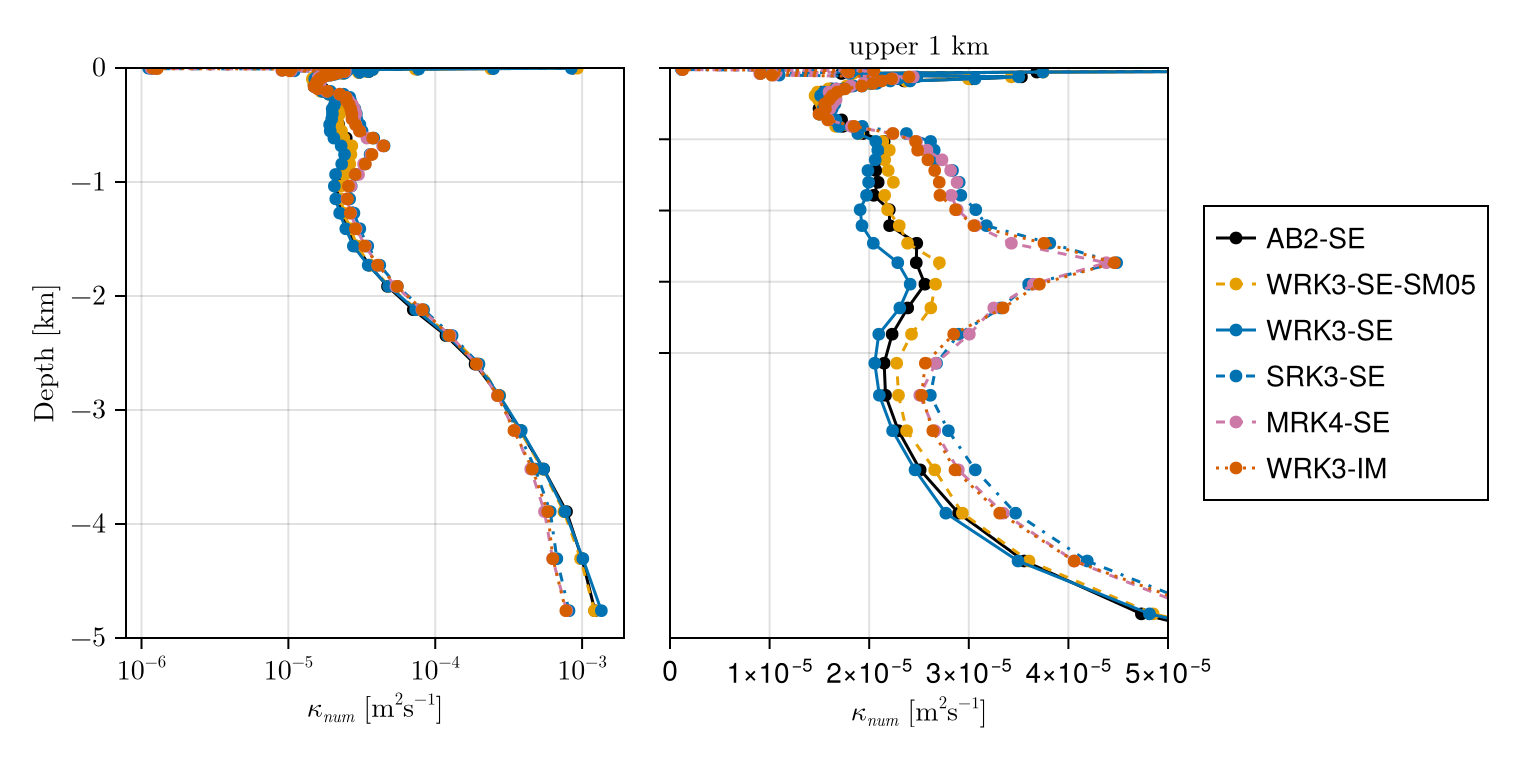

CairoMakie.Screen{PDF}


In [64]:

direction = Colon()
excluded_bottom_cells = 0

profiles = [near_global_diffusivity_profile(c) for c in cases]
# profiles_d = [near_global_diffusivity_profile(c; excluded_bottom_cells=5) for c in cases]
# profiles_x = [near_global_diffusivity_profile(c; direction=1) for c in cases]
# profiles_y = [near_global_diffusivity_profile(c; direction=2) for c in cases]
# profiles_z = [near_global_diffusivity_profile(c; direction=3) for c in cases]

fig = Figure(size = (760, 380))
xt = ([1e-6, 1e-5, 1e-4, 1e-3, 1e-2], [L"10^{-6}", L"10^{-5}", L"10^{-4}", L"10^{-3}", L"10^{-2}"])

ax1 = Axis(fig[1, 1]; xlabel = L"\kappa_{num} \text{ [m}^2\text{s}^{-1}\text{]}", xticks = xt, xscale = log10,
           ylabel = L"\text{Depth [km]}", yticks = ticks([-5, -4, -3, -2, -1, 0]))
ax2 = Axis(fig[1, 2]; xlabel = L"\kappa_{num} \text{ [m}^2\text{s}^{-1}\text{]}", # xticks = xt, # xscale = log10,
           ylabel = "", yticks = ([-1, -0.75, -0.5, -0.25, 0], ["", "", "", "", ""]),
           title = L"\text{upper 1 km}")

for (i, (κ, z)) in enumerate(profiles)
    for ax in (ax1, ax2)
        scatterlines!(ax, positive_branch.(κ), z ./ 1000, color = colors[i], linestyle = styles[i], label = labels[i])
        scatterlines!(ax, negative_branch.(κ), z ./ 1000, color = colors[i], linestyle = :dot)
    end
end
# for (i, (κ, z)) in enumerate(profiles_d)
#     for ax in (ax1, ax2)
#         scatterlines!(ax, positive_branch.(κ), z ./ 1000, color = :blue, linestyle = styles[i], label = labels[i])
#         scatterlines!(ax, negative_branch.(κ), z ./ 1000, color = :blue, linestyle = :dot)
#     end
# end
# for (i, (κ, z)) in enumerate(profiles_x)
#     for ax in (ax1, ax2)
#         scatterlines!(ax, positive_branch.(κ), z ./ 1000, color = :red, linestyle = styles[i], label = labels[i])
#         scatterlines!(ax, negative_branch.(κ), z ./ 1000, color = :red, linestyle = :dot)
#     end
# end
# for (i, (κ, z)) in enumerate(profiles_y)
#     for ax in (ax1, ax2)
#         scatterlines!(ax, positive_branch.(κ), z ./ 1000, color = :green, linestyle = styles[i], label = labels[i])
#         scatterlines!(ax, negative_branch.(κ), z ./ 1000, color = :green, linestyle = :dot)
#     end
# end

# for (i, (κ, z)) in enumerate(profiles_z)
#     for ax in (ax1, ax2)
#         scatterlines!(ax, positive_branch.(κ), z ./ 1000, color = :purple, linestyle = styles[i], label = labels[i])
#         scatterlines!(ax, negative_branch.(κ), z ./ 1000, color = :purple, linestyle = :dot)
#     end
# end


ylims!(ax1, -5, 0)
ylims!(ax2, -2, 0)
xlims!(ax2, 0, 5e-5)
Legend(fig[1, 3], ax1, merge = true)
display(current_figure())
CairoMakie.save(path * "dissipation-near-global.pdf", fig)


## Numerical diffusivity, depth-integrated map

The same ratio taken column by column, `κ(λ, φ) = -Σ_z(A) / 2Σ_z(G)`. This is a local ratio and the
denominator gets small in weakly stratified columns, so the colour scale is saturated well below the extremes
— read where the mixing is, not how large the outliers get.

In [65]:

maps = [near_global_diffusivity_map(c) for c in cases]

κsaturation = 5e-3
ncols = min(3, length(cases))
nrows = cld(length(cases), ncols)

fig = Figure(size = (420 * ncols, 230 * nrows + 60))
heatmap_handle = nothing

for (i, (κ, λ, φ)) in enumerate(maps)
    row, col = fldmod1(i, ncols)
    first_column = col == 1
    last_row = row == nrows

    ax = Axis(fig[row, col]; title = labels[i],
              xlabel = last_row ? L"\text{Longitude}" : "",
              ylabel = first_column ? L"\text{Latitude}" : "",
              xticks = last_row ? ticks([0, 90, 180, 270, 360]) : ([0, 90, 180, 270, 360], fill("", 5)),
              yticks = first_column ? ticks([-60, -30, 0, 30, 60]) : ([-60, -30, 0, 30, 60], fill("", 5)))

    global heatmap_handle = heatmap!(ax, λ, φ, κ; colormap = :balance, nan_color = land_color,
                                     colorrange = (-κsaturation, κsaturation))
    xlims!(ax, 0, 360)
    ylims!(ax, -75, 75)
end

Colorbar(fig[1:nrows, ncols+1], heatmap_handle, label = L"\kappa_{num} \text{ [m}^2\text{s}^{-1}\text{]}")
display(current_figure())
CairoMakie.save(path * "dissipation-near-global-map.pdf", fig)

LoadError: MethodError: no method matching λnodes(::ImmersedBoundaryGrid{…}, ::Center, ::Center)
The function `λnodes` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  λnodes(::ImmersedBoundaryGrid, ::Any, ::Any, [91m::Any[39m; kwargs...)
[0m[90m   @[39m [32mOceananigans[39m [90m~/.julia/packages/Oceananigans/ZmMdD/src/ImmersedBoundaries/[39m[90m[4mimmersed_boundary_nodes.jl:48[24m[39m
[0m  λnodes([91m::LatitudeLongitudeGrid[39m, ::Any, ::Any, [91m::Any[39m; with_halos, indices)
[0m[90m   @[39m [32mOceananigans[39m [90m~/.julia/packages/Oceananigans/ZmMdD/src/Grids/[39m[90m[4mlatitude_longitude_grid.jl:679[24m[39m
[0m  λnodes([91m::OrthogonalSphericalShellGrid[39m, ::Center, ::Center; with_halos, indices)
[0m[90m   @[39m [32mOceananigans[39m [90m~/.julia/packages/Oceananigans/ZmMdD/src/Grids/[39m[90m[4morthogonal_spherical_shell_grid.jl:535[24m[39m
[0m  ...



## Surface state

Surface speed of the last daily snapshot, and the surface temperature of the 30-day average against the
implicit-free-surface reference. `WRK3-IM` is the reference because it removes the barotropic splitting
altogether, so what remains in the difference is what the splitting does.

In [66]:

speeds = [near_global_surface_speed(c) for c in cases]

ncols = min(3, length(cases))
nrows = cld(length(cases), ncols)
fig = Figure(size = (420 * ncols, 230 * nrows + 60))
heatmap_handle = nothing

for (i, (speed, λ, φ)) in enumerate(speeds)
    row, col = fldmod1(i, ncols)
    ax = Axis(fig[row, col]; title = labels[i],
              xlabel = row == nrows ? L"\text{Longitude}" : "",
              ylabel = col == 1 ? L"\text{Latitude}" : "",
              xticks = row == nrows ? ticks([0, 90, 180, 270, 360]) : ([0, 90, 180, 270, 360], fill("", 5)),
              yticks = col == 1 ? ticks([-60, -30, 0, 30, 60]) : ([-60, -30, 0, 30, 60], fill("", 5)))

    global heatmap_handle = heatmap!(ax, λ, φ, speed; colormap = :magma, nan_color = land_color,
                                     colorrange = (0, 1.2))
    xlims!(ax, 0, 360); ylims!(ax, -75, 75)
end

Colorbar(fig[1:nrows, ncols+1], heatmap_handle, label = L"|\mathbf{u}_s| \text{ [m s}^{-1}\text{]}")
display(current_figure())
CairoMakie.save(path * "surface-speed-near-global.pdf", fig)

LoadError: MethodError: no method matching λnodes(::ImmersedBoundaryGrid{…}, ::Center, ::Center)
The function `λnodes` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  λnodes(::ImmersedBoundaryGrid, ::Any, ::Any, [91m::Any[39m; kwargs...)
[0m[90m   @[39m [32mOceananigans[39m [90m~/.julia/packages/Oceananigans/ZmMdD/src/ImmersedBoundaries/[39m[90m[4mimmersed_boundary_nodes.jl:48[24m[39m
[0m  λnodes([91m::LatitudeLongitudeGrid[39m, ::Any, ::Any, [91m::Any[39m; with_halos, indices)
[0m[90m   @[39m [32mOceananigans[39m [90m~/.julia/packages/Oceananigans/ZmMdD/src/Grids/[39m[90m[4mlatitude_longitude_grid.jl:679[24m[39m
[0m  λnodes([91m::OrthogonalSphericalShellGrid[39m, ::Center, ::Center; with_halos, indices)
[0m[90m   @[39m [32mOceananigans[39m [90m~/.julia/packages/Oceananigans/ZmMdD/src/Grids/[39m[90m[4morthogonal_spherical_shell_grid.jl:535[24m[39m
[0m  ...


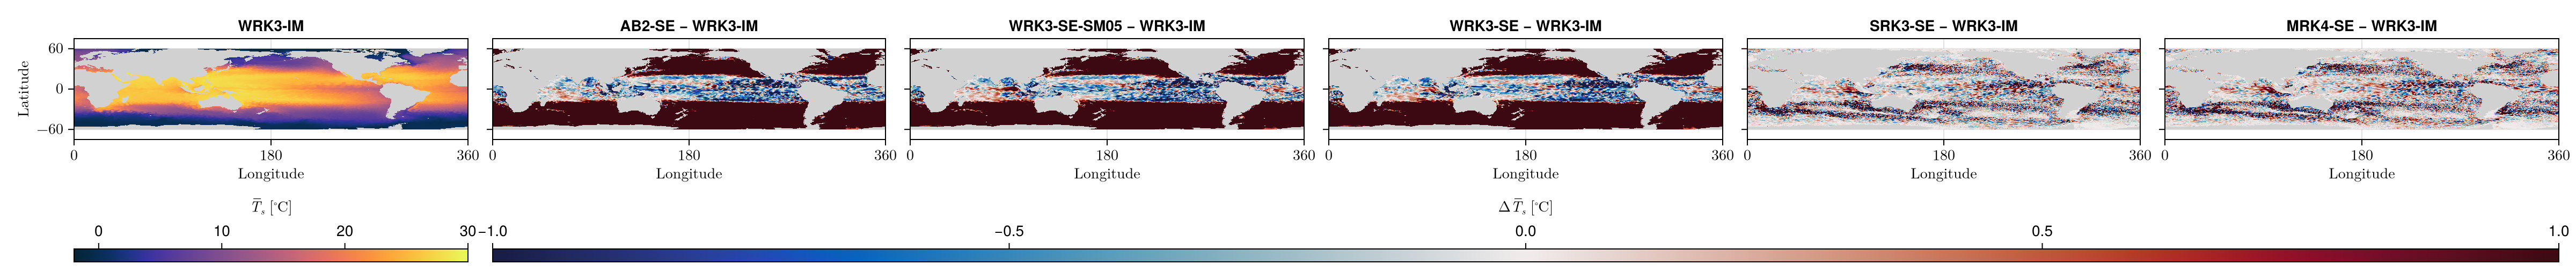

CairoMakie.Screen{PDF}


In [67]:

# Surface temperature of the 30-day average, and every other case as a difference against WRK3-IM.
reference_index = findfirst(==("WRK3-IM"), labels)

surface_average(c, name) = begin
    field = Array(interior(c[Symbol(name)][end], :, :, 1))
    masked = copy(field)
    masked[field .== 0] .= NaN
    masked
end

λC = Array(Oceananigans.Grids.λnodes(cases[1][:T̄].grid, Center()))
φC = Array(Oceananigans.Grids.φnodes(cases[1][:T̄].grid, Center()))

if isnothing(reference_index)
    @warn "WRK3-IM is not on disk yet; the difference panels need it as the reference"
else
    T̄ref = surface_average(cases[reference_index], :T̄)
    others = [i for i in eachindex(labels) if i != reference_index]

    fig = Figure(size = (400 * (length(others) + 1), 260))
    ax = Axis(fig[1, 1]; title = labels[reference_index], xlabel = L"\text{Longitude}",
              ylabel = L"\text{Latitude}", xticks = ticks([0, 180, 360]), yticks = ticks([-60, 0, 60]))
    hm = heatmap!(ax, λC, φC, T̄ref; colormap = :thermal, nan_color = land_color, colorrange = (-2, 30))
    Colorbar(fig[2, 1], hm, vertical = false, label = L"\overline{T}_s \text{ [}^\circ\text{C]}")
    xlims!(ax, 0, 360); ylims!(ax, -75, 75)

    difference_handle = nothing
    for (col, i) in enumerate(others)
        axd = Axis(fig[1, col+1]; title = labels[i] * " − " * labels[reference_index],
                   xlabel = L"\text{Longitude}", ylabel = "",
                   xticks = ticks([0, 180, 360]), yticks = ([-60, 0, 60], ["", "", ""]))
        global difference_handle = heatmap!(axd, λC, φC, surface_average(cases[i], :T̄) .- T̄ref;
                                     colormap = :balance, nan_color = land_color, colorrange = (-1, 1))
        xlims!(axd, 0, 360); ylims!(axd, -75, 75)
    end

    Colorbar(fig[2, 2:length(others)+1], difference_handle, vertical = false,
             label = L"\Delta \overline{T}_s \text{ [}^\circ\text{C]}")
    display(current_figure())
    CairoMakie.save(path * "surface-temperature-near-global.pdf", fig)
end


## Surface kinetic energy and eddy kinetic energy

Instantaneous surface kinetic energy of the last daily snapshot, and the eddy kinetic energy accumulated over
the daily series, `⟨(u - ⟨u⟩)² + (v - ⟨v⟩)²⟩/2`. EKE reads one snapshot per output time per case, so restrict
`time_indices` where the series is long.

In [68]:

# The daily series is read snapshot by snapshot: one pass per case, so this is the slow cell of the notebook.
# The window is the shortest series on disk, so that the cases are averaged over the same interval even while
# some of them are still integrating.
eke_window = 1:minimum(length(c[:surface_times]) for c in cases)
@info "Eddy kinetic energy averaged over $(length(eke_window)) daily snapshots"
eddy_energies = [near_global_eddy_kinetic_energy(c; time_indices = eke_window) for c in cases]

ncols = min(3, length(cases))
nrows = cld(length(cases), ncols)
fig = Figure(size = (420 * ncols, 230 * nrows + 60))
heatmap_handle = nothing

for (i, (eke, λ, φ)) in enumerate(eddy_energies)
    row, col = fldmod1(i, ncols)
    ax = Axis(fig[row, col]; title = labels[i],
              xlabel = row == nrows ? L"\text{Longitude}" : "",
              ylabel = col == 1 ? L"\text{Latitude}" : "",
              xticks = row == nrows ? ticks([0, 90, 180, 270, 360]) : ([0, 90, 180, 270, 360], fill("", 5)),
              yticks = col == 1 ? ticks([-60, -30, 0, 30, 60]) : ([-60, -30, 0, 30, 60], fill("", 5)))

    global heatmap_handle = heatmap!(ax, λ, φ, log10.(eke); colormap = :speed, nan_color = land_color,
                                     colorrange = (-4, -1))
    xlims!(ax, 0, 360); ylims!(ax, -75, 75)
end

Colorbar(fig[1:nrows, ncols+1], heatmap_handle,
         label = L"\log_{10} \text{EKE} \text{ [m}^2\text{s}^{-2}\text{]}")
display(current_figure())
CairoMakie.save(path * "eke-near-global.pdf", fig)

[ Info: Eddy kinetic energy averaged over 721 daily snapshots


LoadError: MethodError: no method matching λnodes(::ImmersedBoundaryGrid{…}, ::Center, ::Center)
The function `λnodes` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  λnodes(::ImmersedBoundaryGrid, ::Any, ::Any, [91m::Any[39m; kwargs...)
[0m[90m   @[39m [32mOceananigans[39m [90m~/.julia/packages/Oceananigans/ZmMdD/src/ImmersedBoundaries/[39m[90m[4mimmersed_boundary_nodes.jl:48[24m[39m
[0m  λnodes([91m::LatitudeLongitudeGrid[39m, ::Any, ::Any, [91m::Any[39m; with_halos, indices)
[0m[90m   @[39m [32mOceananigans[39m [90m~/.julia/packages/Oceananigans/ZmMdD/src/Grids/[39m[90m[4mlatitude_longitude_grid.jl:679[24m[39m
[0m  λnodes([91m::OrthogonalSphericalShellGrid[39m, ::Center, ::Center; with_halos, indices)
[0m[90m   @[39m [32mOceananigans[39m [90m~/.julia/packages/Oceananigans/ZmMdD/src/Grids/[39m[90m[4morthogonal_spherical_shell_grid.jl:535[24m[39m
[0m  ...



## Zonal spectra in the circumpolar band

The one band of this configuration worth a zonal transform: 60°S–56°S is periodic in the physical sense and
entirely free of land — south of Cape Horn, north of the Antarctic Peninsula — so the transform sees an
actual periodic signal rather than a coastline. Every latitude between 55°S and 45°S clips South America.

Each row is transformed on its own spacing, `Δx = 2πR cos φ / Nx`, and interpolated onto the wavenumber axis
of the band's central latitude before being averaged. A single snapshot carries one realization per
wavenumber and its scatter is of the order of the estimate itself, which is why the transform is also
averaged in time: the sixteen rows of the band alone do not smooth a periodogram. The daily snapshots are
correlated over the eddy time scale, so the window is subsampled every fifth day and the count of
decorrelated realizations, rather than the count of files read, is what brings the scatter down as `1/√n`.

The grid scale is marked: what separates the schemes is how much power survives approaching it, which is
where a dissipative barotropic filter shows up.


In [69]:
# The second year, every fifth day: one snapshot per case is a periodogram and the daily series is correlated
# over the eddy time scale, so subsampling costs realizations that are nearly free while the reads are not.
spectrum_window = 361:5:minimum(length(c[:surface_times]) for c in cases)
@info "Zonal spectra averaged over $(length(spectrum_window)) snapshots"

spectra = [(near_global_zonal_spectrum(c, :u; time_indices = spectrum_window) .+
            near_global_zonal_spectrum(c, :v; time_indices = spectrum_window)) ./ 2 for c in cases]

[ Info: Zonal spectra averaged over 73 snapshots


LoadError: MethodError: no method matching φnodes(::ImmersedBoundaryGrid{…}, ::Center, ::Center)
The function `φnodes` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  φnodes(::ImmersedBoundaryGrid, ::Any, ::Any, [91m::Any[39m; kwargs...)
[0m[90m   @[39m [32mOceananigans[39m [90m~/.julia/packages/Oceananigans/ZmMdD/src/ImmersedBoundaries/[39m[90m[4mimmersed_boundary_nodes.jl:49[24m[39m
[0m  φnodes([91m::LatitudeLongitudeGrid[39m, ::Any, ::Any, [91m::Any[39m; with_halos, indices)
[0m[90m   @[39m [32mOceananigans[39m [90m~/.julia/packages/Oceananigans/ZmMdD/src/Grids/[39m[90m[4mlatitude_longitude_grid.jl:680[24m[39m
[0m  φnodes([91m::OrthogonalSphericalShellGrid[39m, ::Center, ::Center; with_halos, indices)
[0m[90m   @[39m [32mOceananigans[39m [90m~/.julia/packages/Oceananigans/ZmMdD/src/Grids/[39m[90m[4morthogonal_spherical_shell_grid.jl:547[24m[39m
[0m  ...


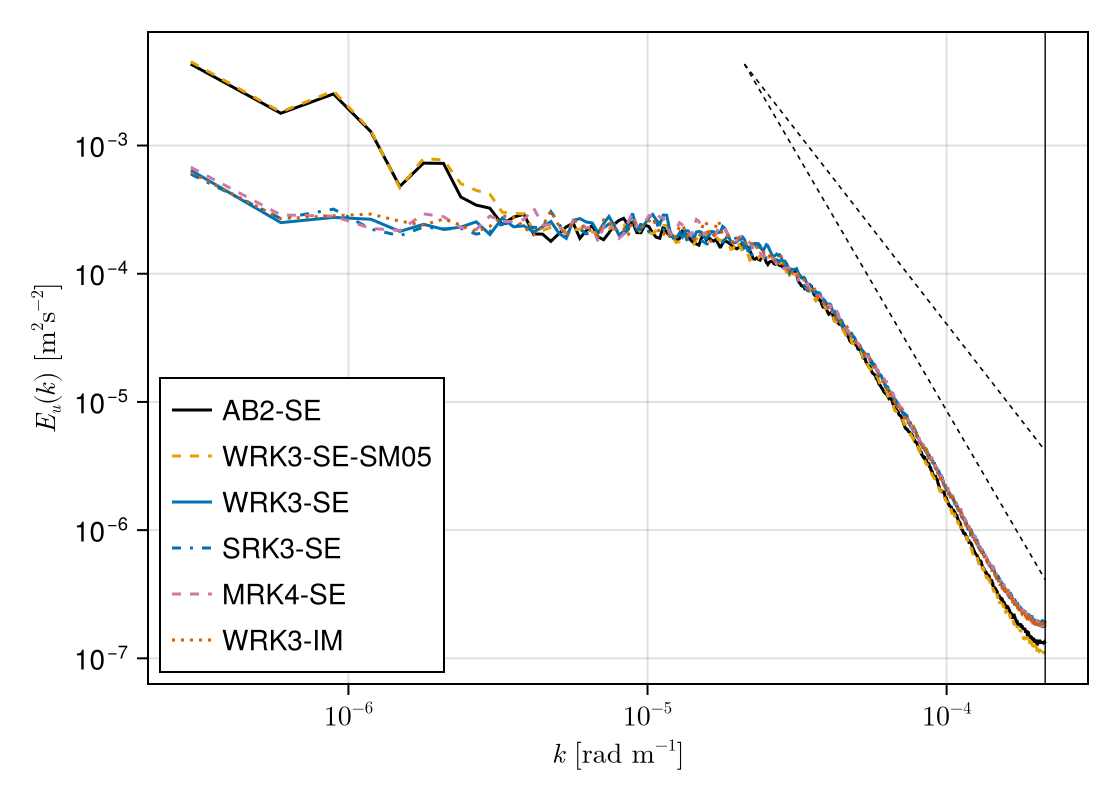

CairoMakie.Screen{PDF}


In [70]:
fig = Figure(size = (560, 400))
ax = Axis(fig[1, 1]; xlabel = L"k \text{ [rad m}^{-1}\text{]}", ylabel = L"E_u(k) \text{ [m}^2\text{s}^{-2}\text{]}",
          xscale = log10, yscale = log10,
          xticks = ([1e-6, 1e-5, 1e-4], [L"10^{-6}", L"10^{-5}", L"10^{-4}"]))

for (i, (spectrum, wavenumber)) in enumerate(spectra)
    lines!(ax, wavenumber[2:end], max.(spectrum[2:end], 1e-16),
           color = colors[i], linestyle = styles[i], label = labels[i])
end

# -3 slope for reference, anchored on the first case at the low-wavenumber end of the resolved range
kref = spectra[1][2][end÷10:end]
lines!(ax, kref, spectra[1][1][2] .* (kref ./ kref[1]) .^ (-3) * 1, color = :black, linestyle = :dash, linewidth = 0.8)
lines!(ax, kref, spectra[1][1][2] .* (kref ./ kref[1]) .^ (-4) * 1, color = :black, linestyle = :dash, linewidth = 0.8)

# the grid scale, where a dissipative barotropic filter takes the power down
vlines!(ax, spectra[1][2][end], color = :black, linewidth = 0.7)
axislegend(ax; position = :lb, merge = true)
display(current_figure())
CairoMakie.save(path * "spectra-near-global.pdf", fig)


## Cost (Section 5.4.1)

Read from the `_cost` records that `near_global` writes beside the field output. A scheme that costs more per
step but takes a longer step can still finish the year first, which is what `simulated days per wall day`
shows: it is `Δt / seconds per step`, and it is the column the comparison turns on.

Runs that predate the cost record leave `case[:cost] === nothing` and are skipped.

In [71]:
costs = near_global_cost_table(cases)

if isempty(costs)
    @warn "No cost record on disk. Re-run `near_global/test.jl` -- `near_global` now writes " *
          "near_global_<label>_cost.jld2 beside the field output."
else
    @printf("%-14s %10s %9s %12s %12s %8s\n", "case", "Δt [min]", "substeps", "s/step", "sim d / d", "speedup")
    for r in costs
        @printf("%-14s %10.2f %9d %12.4f %12.1f %8.2f\n",
                r.label, r.Δt / 60, r.substeps, r.seconds_per_step, r.simulated_days_per_day, r.speedup)
    end
end

case             Δt [min]  substeps       s/step    sim d / d  speedup
AB2-SE               5.80        28       0.2545       1367.9     1.00
WRK3-SE-SM05        20.00        92       0.6722       1785.2     1.31
WRK3-SE             20.00        70       0.6769       1772.9     1.30
SRK3-SE             20.00       113       0.7662       1566.1     1.14
MRK4-SE             31.81       177       1.1235       1699.0     1.24
WRK3-IM             20.00         0       1.2979        924.6     0.68


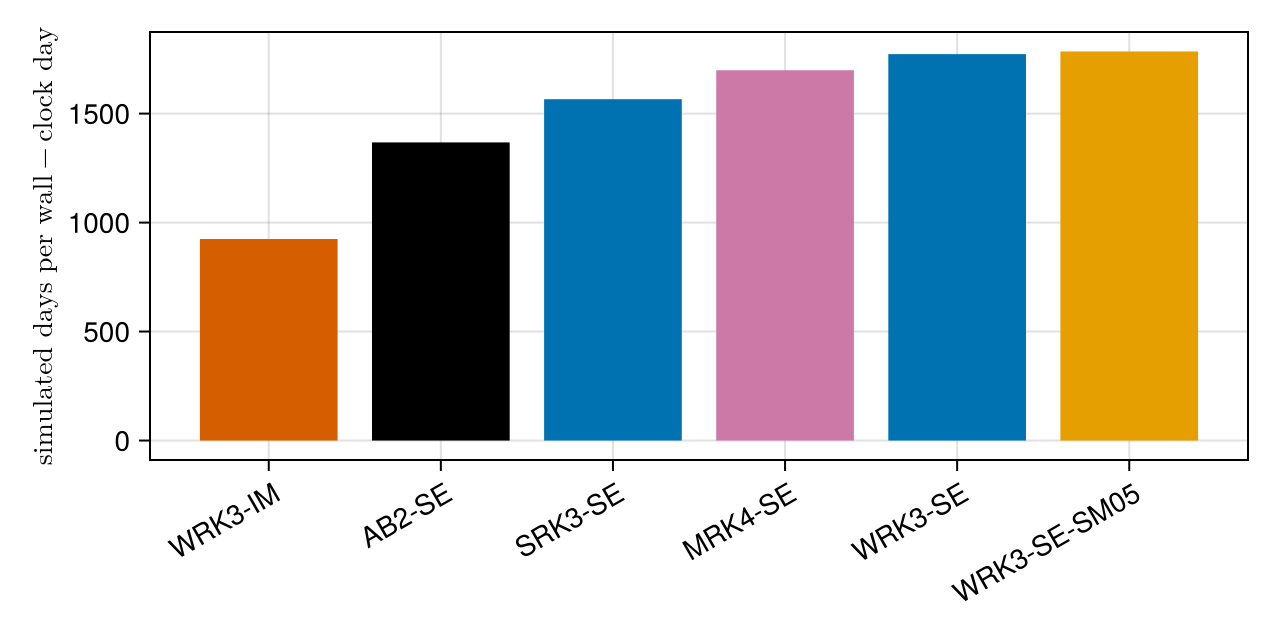

CairoMakie.Screen{PDF}


In [72]:
if !isempty(costs)
    order = sortperm([c.simulated_days_per_day for c in costs])
    fig = Figure(size = (640, 320))
    ax = Axis(fig[1, 1]; ylabel = L"\text{simulated days per wall-clock day}",
              xticks = (1:length(costs), [costs[i].label for i in order]),
              xticklabelrotation = π/6)

    barplot!(ax, 1:length(costs), [costs[i].simulated_days_per_day for i in order],
             color = [plot_style(costs[i].label).color for i in order])

    display(current_figure())
    CairoMakie.save(path * "cost-near-global.pdf", fig)
end


## Hovmöller of the numerical diffusivity

`κ(z, t)` over the dissipation output series, one panel per case. Each column is a global reduction, so with
the 30-day `AveragedTimeInterval` this is cheap; subsample `time_indices` if the interval is shortened.

In [73]:
hovmollers = [near_global_diffusivity_hovmoller(c) for c in cases]

6-element Vector{Tuple{Matrix{Float64}, Vector{Float64}, StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}}}:
 ([-0.0 0.00257689232242851 … 0.0012281978830621508 0.00122145488658813; -0.0 0.0038857001290649945 … 0.001009336001772192 0.0009986751194458361; … ; -0.0 8.214819547907652e-5 … 0.00016253934760608303 0.00024258752798962186; -0.0 0.00018218974619948613 … 0.0007016418064089456 0.0008650337652181676], [-4760.479669799808, -4304.232382454151, -3891.402764986395, -3517.859079828099, -3179.8627762258284, -2874.031073568653, -2597.303105382792, -2346.9092851511605, -2120.343587360611, -1915.3384663562942  …  -53.89418690574092, -45.53772634675333, -37.97648815063967, -31.1347969041133, -24.94417866160716, -19.342675635011595, -14.27422609930625, -9.688103307973066, -5.538407802667282, -1.7836080360109687], 0.0:2.592e6:6.2208e7)
 ([-0.0 0.002844461586393835 … 0.0011955809147103191 0.0012124337953280848; -0.0 0.004233690155917324 … 0.0010019267479

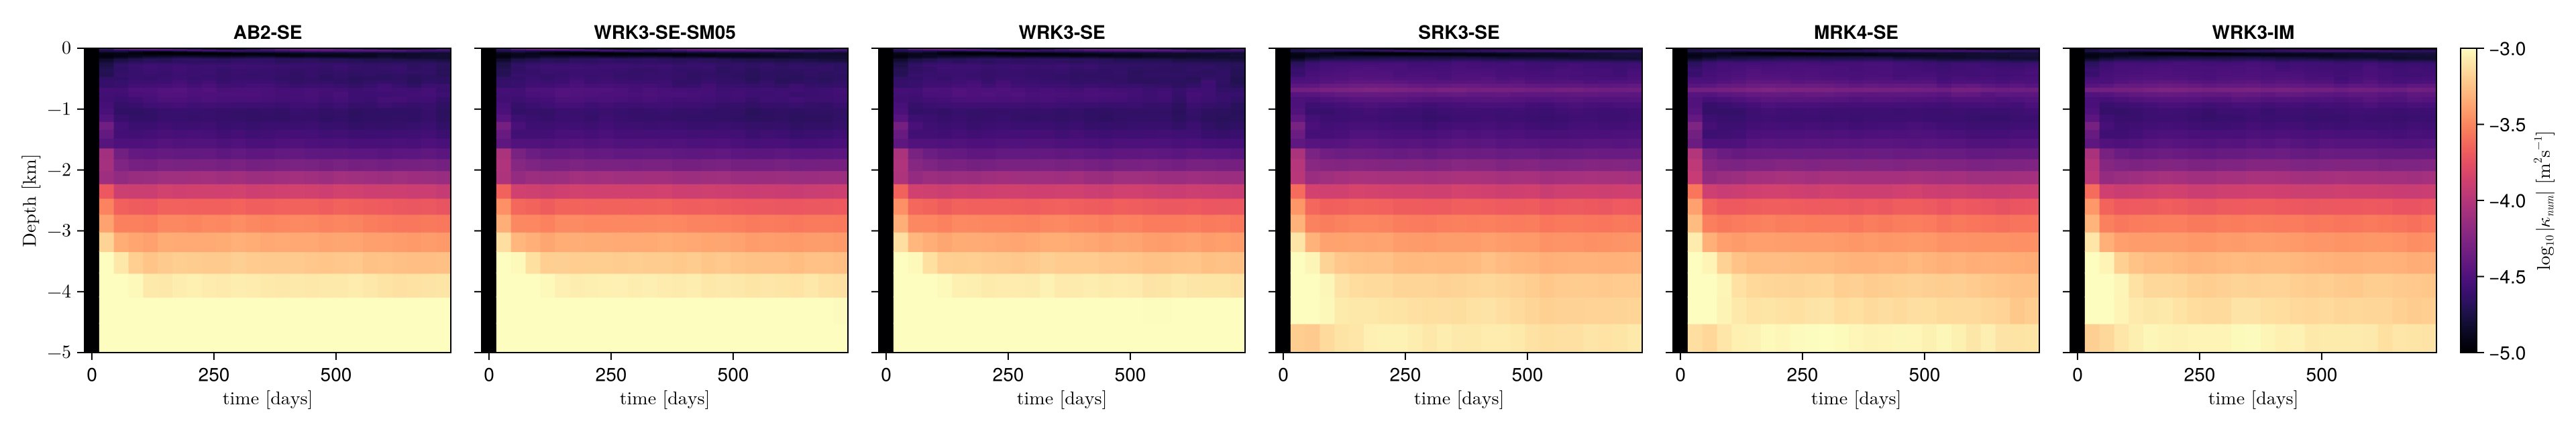

CairoMakie.Screen{PDF}


In [74]:
if length(cases[1][:times]) < 3
    @info "Fewer than three dissipation snapshots on disk -- the Hovmöller needs a longer run"
else
    fig = Figure(size = (300 * length(cases) + 120, 320))
    heatmap_handle = nothing

    for (i, (κ, z, times)) in enumerate(hovmollers)
        ax = Axis(fig[1, i]; title = labels[i], xlabel = L"\text{time [days]}",
                  ylabel = i == 1 ? L"\text{Depth [km]}" : "",
                  yticks = i == 1 ? ticks([-5, -4, -3, -2, -1, 0]) :
                                    ([-5, -4, -3, -2, -1, 0], fill("", 6)))

        global heatmap_handle = heatmap!(ax, times ./ 86400, z ./ 1000, permutedims(log10.(abs.(κ)));
                                         colormap = :magma, nan_color = land_color, colorrange = (-5, -3))
        ylims!(ax, -5, 0)
    end

    Colorbar(fig[1, length(cases)+1], heatmap_handle,
             label = L"\log_{10} |\kappa_{num}| \text{ [m}^2\text{s}^{-1}\text{]}")
    display(current_figure())
    CairoMakie.save(path * "diffusivity-hovmoller-near-global.pdf", fig)
end

In [75]:
# Surface kinetic energy of the daily series, globally and over the circumpolar band the spectra transform.
# One pass per case per curve, so the series is subsampled: the drift is what matters here, not the day-to-day.
history_window = 1:5:minimum(length(c[:surface_times]) for c in cases)

global_histories = [near_global_surface_kinetic_energy_history(c; time_indices = history_window) for c in cases]
band_histories   = [near_global_surface_kinetic_energy_history(c; time_indices = history_window,
                                                               latitude_band = (-60, -56)) for c in cases]

fig = Figure(size = (760, 340))
ax1 = Axis(fig[1, 1]; xlabel = L"\text{time [days]}", ylabel = L"\overline{E}_s \text{ [m}^2\text{s}^{-2}\text{]}",
           title = L"\text{global}")
ax2 = Axis(fig[1, 2]; xlabel = L"\text{time [days]}", ylabel = "", title = L"60^\circ\text{S--}56^\circ\text{S}")

for (ax, histories) in zip((ax1, ax2), (global_histories, band_histories))
    for (i, (times, kinetic_energy)) in enumerate(histories)
        lines!(ax, times ./ 86400, kinetic_energy, color = colors[i], linestyle = styles[i], label = labels[i])
    end
end

Legend(fig[1, 3], ax1, merge = true)
display(current_figure())
CairoMakie.save(path * "kinetic-energy-history-near-global.pdf", fig)

LoadError: MethodError: no method matching φnodes(::ImmersedBoundaryGrid{…}, ::Center, ::Center)
The function `φnodes` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  φnodes(::ImmersedBoundaryGrid, ::Any, ::Any, [91m::Any[39m; kwargs...)
[0m[90m   @[39m [32mOceananigans[39m [90m~/.julia/packages/Oceananigans/ZmMdD/src/ImmersedBoundaries/[39m[90m[4mimmersed_boundary_nodes.jl:49[24m[39m
[0m  φnodes([91m::LatitudeLongitudeGrid[39m, ::Any, ::Any, [91m::Any[39m; with_halos, indices)
[0m[90m   @[39m [32mOceananigans[39m [90m~/.julia/packages/Oceananigans/ZmMdD/src/Grids/[39m[90m[4mlatitude_longitude_grid.jl:680[24m[39m
[0m  φnodes([91m::OrthogonalSphericalShellGrid[39m, ::Center, ::Center; with_halos, indices)
[0m[90m   @[39m [32mOceananigans[39m [90m~/.julia/packages/Oceananigans/ZmMdD/src/Grids/[39m[90m[4morthogonal_spherical_shell_grid.jl:547[24m[39m
[0m  ...
